In [10]:
import os, sys, glob
import math
import collections
import copy
import json

In [11]:
import ROOT

In [12]:
ANA_DIR = os.path.expanduser("/home/das214/HHtobbtautau/Scouting/CMSSW_15_0_15/src/Ana")
os.chdir(ANA_DIR)
sys.path.insert(0, ANA_DIR)

ROOT.gInterpreter.AddIncludePath(ANA_DIR)  
ROOT.gROOT.LoadMacro("Particle.h+")
ROOT.gROOT.LoadMacro("HHbbtautauAnaElements.C+")

print("CWD =", os.getcwd())
print("sys.path[0] =", sys.path[0])

ROOT.gErrorIgnoreLevel = ROOT.kInfo  # show more
# ROOT.ROOT.EnableImplicitMT()         # Enable multithreading
ROOT.ROOT.DisableImplicitMT()

print("CWD =", os.getcwd())
print("sys.path[0] =", sys.path[0])

CWD = /home/das214/HHtobbtautau/Scouting/CMSSW_15_0_15/src/Ana
sys.path[0] = /home/das214/HHtobbtautau/Scouting/CMSSW_15_0_15/src/Ana
CWD = /home/das214/HHtobbtautau/Scouting/CMSSW_15_0_15/src/Ana
sys.path[0] = /home/das214/HHtobbtautau/Scouting/CMSSW_15_0_15/src/Ana


Info in <ACLiC>: unmodified script has already been compiled and loaded
Info in <ACLiC>: unmodified script has already been compiled and loaded
Warning in <ROOT_TImplicitMT_DisableImplicitMT>: Implicit multi-threading is already disabled


In [13]:
import anaConfig
from ROOT import Ana, TCanvas, TH1D, TPad, TLegend, THStack, RDataFrame
from argparse import ArgumentParser

In [14]:
def ls_nanoaod_files_from_fs(
    base_dir,
    sample,
    dataset_tag=None,          # if None: auto-pick if unique, else error w/ choices
    production_id=None,        # if None: pick lexicographically latest (YYMMDD_HHMMSS)
    pattern="*.root",          # adjust if needed (e.g. "nano*.root")
    recursive=True,
    verbose=0,
):
    base_dir = os.path.abspath(base_dir)
    sample_dir = os.path.join(base_dir, sample)
    if not os.path.isdir(sample_dir):
        avail = sorted(
            d for d in os.listdir(base_dir)
            if os.path.isdir(os.path.join(base_dir, d))
        )
        raise FileNotFoundError(
            f"Sample dir not found:\n  {sample_dir}\n"
            f"Available samples under {base_dir}:\n  - " + "\n  - ".join(avail)
        )

    # dataset_tag selection
    dataset_tags = sorted(
        d for d in os.listdir(sample_dir)
        if os.path.isdir(os.path.join(sample_dir, d))
    )
    if not dataset_tags:
        raise FileNotFoundError(f"No dataset_tag dirs under:\n  {sample_dir}")

    if dataset_tag is None:
        if len(dataset_tags) == 1:
            dataset_tag = dataset_tags[0]
        else:
            raise ValueError(
                f"Multiple dataset_tag dirs under:\n  {sample_dir}\n"
                f"Pass dataset_tag=... one of:\n  - " + "\n  - ".join(dataset_tags)
            )
    else:
        if dataset_tag not in dataset_tags:
            raise ValueError(
                f"dataset_tag '{dataset_tag}' not found under:\n  {sample_dir}\n"
                f"Available:\n  - " + "\n  - ".join(dataset_tags)
            )

    dataset_dir = os.path.join(sample_dir, dataset_tag)

    # production_id selection
    prod_ids = sorted(
        d for d in os.listdir(dataset_dir)
        if os.path.isdir(os.path.join(dataset_dir, d))
    )
    if not prod_ids:
        raise FileNotFoundError(f"No production_id dirs under:\n  {dataset_dir}")

    if production_id is None:
        production_id = prod_ids[-1]   # YYMMDD_HHMMSS => lexicographic sort works
    else:
        if production_id not in prod_ids:
            raise ValueError(
                f"production_id '{production_id}' not found under:\n  {dataset_dir}\n"
                f"Available:\n  - " + "\n  - ".join(prod_ids)
            )

    prod_dir = os.path.join(dataset_dir, production_id)

    # collect files
    if recursive:
        file_glob = os.path.join(prod_dir, "**", pattern)
        files = sorted(glob.glob(file_glob, recursive=True))
    else:
        file_glob = os.path.join(prod_dir, pattern)
        files = sorted(glob.glob(file_glob))

    # basic sanity: keep only real files
    files = [f for f in files if os.path.isfile(f)]

    if verbose:
        print(f"[ls_nanoaod_files_from_fs]")
        print(f"  base_dir      = {base_dir}")
        print(f"  sample        = {sample}")
        print(f"  dataset_tag   = {dataset_tag}")
        print(f"  production_id = {production_id}")
        print(f"  glob          = {file_glob}")
        print(f"  nfiles        = {len(files)}")
        if verbose > 1:
            for f in files[:10]:
                print("   ", f)

    if not files:
        raise FileNotFoundError(
            f"No ROOT files matched.\n"
            f"  prod_dir   = {prod_dir}\n"
            f"  pattern    = {pattern}\n"
            f"  recursive  = {recursive}\n"
            f"Try pattern='*.root' (already default) or pattern='nano*.root' and keep recursive=True."
        )

    return files


def ls_nanoaod_files_many(
    base_dir,
    samples,                    # list[str] OR dict[str, dict(opts)]
    dataset_tag=None,
    production_id=None,
    pattern="*.root",
    recursive=True,
    verbose=0,
    allow_missing=False,
):
    """
    Bulk collect NanoAOD ROOT files for multiple samples.

    samples can be:
      - list of sample names
      - dict: { sample_name: { 'dataset_tag':..., 'production_id':..., 'pattern':... } }
        (per-sample overrides)
    """
    if isinstance(samples, dict):
        sample_names = list(samples.keys())
        per_sample_opts = samples
    else:
        sample_names = list(samples)
        per_sample_opts = {}

    files_by_sample = {}
    all_files = []

    for s in sample_names:
        opts = per_sample_opts.get(s, {})
        try:
            files = ls_nanoaod_files_from_fs(
                base_dir=base_dir,
                sample=s,
                dataset_tag=opts.get("dataset_tag", dataset_tag),
                production_id=opts.get("production_id", production_id),
                pattern=opts.get("pattern", pattern),
                recursive=opts.get("recursive", recursive),
                verbose=verbose,
            )
        except Exception as e:
            if allow_missing:
                if verbose:
                    print(f"[WARN] skipping sample '{s}': {e}")
                continue
            raise

        files_by_sample[s] = files
        all_files.extend(files)

    return files_by_sample, all_files


def ls_nanoaod_files_groups(
    base_dir,
    groups,                     # dict[group_name] = list[str] OR dict[group_name] = dict(sample->opts)
    dataset_tag=None,
    production_id=None,
    pattern="*.root",
    recursive=True,
    verbose=0,
    allow_missing=False,
):
    """
    Collect per-group file lists.
    Returns:
      group_files: dict[group] -> list[str]
      group_files_by_sample: dict[group] -> dict[sample]->list[str]
    """
    group_files = {}
    group_files_by_sample = {}

    for gname, gspec in groups.items():
        by_sample, all_files = ls_nanoaod_files_many(
            base_dir=base_dir,
            samples=gspec,
            dataset_tag=dataset_tag,
            production_id=production_id,
            pattern=pattern,
            recursive=recursive,
            verbose=verbose,
            allow_missing=allow_missing,
        )
        group_files[gname] = all_files
        group_files_by_sample[gname] = by_sample

    return group_files, group_files_by_sample

In [15]:
def dropBranchNames(frame, filename, exclusionlist = []):
	"""
	Writes a list of column (branch) names from a ROOT RDataFrame to a text file,
	excluding any branches whose names contain substrings in the exclusion list.

	Parameters:
		frame         : ROOT.RDataFrame
			The dataframe to extract column names from.
		filename      : str
			The name of the output text file where the column names will be saved.
		exclusionlist : list of str
			List of substrings; any column containing these substrings will be excluded.
	"""
	with open(filename, "w") as file: 
		for name in frame.GetColumnNames(): 
			name = str(name)
			#print("{} {}".format(name, [(excluded in name) for excluded in exclusionlist]))
			if not (any([excluded in name for excluded in exclusionlist])): 
				file.write("{}\n".format(name))


def WriteFile(sample, filename, blacklist, treename = "Events"): 
	sample.Snapshot(treename, filename, Ana.purgeColumns(sample.GetColumnNames(), blacklist))


def generalise(df): 
	return ROOT.ROOT.RDF.AsRNode(df)

In [24]:
BASE = os.path.join(
    "/eos/purdue/store/user/arghyara",
    "production",
    "Scouting",
    "NanoAODv15Scouting24",
    "mcscouting_2024"
)

print(f"BASE directory for MC/data: {BASE}")
print(os.listdir(BASE))

# TODO: Add QCD
 
DY = [
  "DYto2L-2Jets_Bin-2J-MLL-50-PTLL-40to100_TuneCP5_13p6TeV_amcatnloFXFX-pythia8",
  "DYto2L-2Jets_Bin-MLL-50-PTLL-100_TuneCP5_13p6TeV_amcatnloFXFX-pythia8",
  "DYto2L-2Jets_Bin-MLL-50-PTLL-400_TuneCP5_13p6TeV_amcatnloFXFX-pythia8",
  "DYto2L-2Jets_Bin-MLL-50-PTLL-600_TuneCP5_13p6TeV_amcatnloFXFX-pythia8",
]

TT = [
  "TTto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8",
  "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8",
  "TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8",
]

SIG = [
  "GluGluHHto2B2Tau_Par-c2-0p00-kl-0p00-kt-1p00_TuneCP5_13p6TeV_powheg-pythia8",
]

GROUPS = {"DY": DY, "TT": TT, "HHbbtt": SIG}

group_files, _ = ls_nanoaod_files_groups(
    base_dir=BASE,
    groups=GROUPS,
    dataset_tag=None,          # if None: auto-pick if unique, else error w/ choices
    production_id=None,        # if None: pick lexicographically latest (YYMMDD_HHMMSS)
    pattern="*.root",          # adjust if needed (e.g. "nano*.root")
    recursive=True,
    verbose=1,
)

dy_df  = ROOT.RDataFrame("Events", group_files["DY"])
tt_df  = ROOT.RDataFrame("Events", group_files["TT"])
sig_df = ROOT.RDataFrame("Events", group_files["HHbbtt"])

FILE_SIZE = 10_000
dy_df  = ROOT.RDataFrame("Events", group_files["DY"]).Range(FILE_SIZE)
tt_df  = ROOT.RDataFrame("Events", group_files["TT"]).Range(FILE_SIZE)
sig_df = ROOT.RDataFrame("Events", group_files["HHbbtt"]).Range(FILE_SIZE) 

BASE directory for MC/data: /eos/purdue/store/user/arghyara/production/Scouting/NanoAODv15Scouting24/mcscouting_2024
['DYto2L-2Jets_Bin-2J-MLL-50-PTLL-40to100_TuneCP5_13p6TeV_amcatnloFXFX-pythia8', 'DYto2L-2Jets_Bin-MLL-50-PTLL-100_TuneCP5_13p6TeV_amcatnloFXFX-pythia8', 'DYto2L-2Jets_Bin-MLL-50-PTLL-200_TuneCP5_13p6TeV_amcatnloFXFX-pythia8', 'DYto2L-2Jets_Bin-MLL-50-PTLL-400_TuneCP5_13p6TeV_amcatnloFXFX-pythia8', 'DYto2L-2Jets_Bin-MLL-50-PTLL-600_TuneCP5_13p6TeV_amcatnloFXFX-pythia8', 'GluGluHHto2B2Tau_Par-c2-0p00-kl-0p00-kt-1p00_TuneCP5_13p6TeV_powheg-pythia8', 'TTto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8', 'TTto4Q_TuneCP5_13p6TeV_powheg-pythia8', 'TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8']
[ls_nanoaod_files_from_fs]
  base_dir      = /eos/purdue/store/user/arghyara/production/Scouting/NanoAODv15Scouting24/mcscouting_2024
  sample        = DYto2L-2Jets_Bin-2J-MLL-50-PTLL-40to100_TuneCP5_13p6TeV_amcatnloFXFX-pythia8
  dataset_tag   = RunIII2024Summer24MiniAODv6-150X_mcRun3_2024_realistic_

In [25]:
dy_df = dy_df.Define("GenDecay", "Ana::DecayGenMatching({0}_pdgId, {0}_genPartIdxMother, {0}_statusFlags)".format("GenPart"))
tt_df = tt_df.Define("GenDecay", "Ana::DecayGenMatching({0}_pdgId, {0}_genPartIdxMother, {0}_statusFlags)".format("GenPart"))
sig_df = sig_df.Define("GenDecay", "Ana::DecayGenMatching({0}_pdgId, {0}_genPartIdxMother, {0}_statusFlags)".format("GenPart"))

sig_df = (sig_df
    # .Define("gen_mHbb_branch",     "GenPart_mass[genHbb_idx]")
    # .Define("gen_mHtautau_branch", "GenPart_mass[genHtautau_idx]")
    .Define("genHbb_idx",    "(int)GenDecay.Htob")     # Higgs that decays to bb
    .Define("genHtautau_idx","(int)GenDecay.Htotau")   # Higgs that decays to tautau
    .Define("genHbb_p4",     "Ana::getP4(genHbb_idx, GenPart_pt, GenPart_eta, GenPart_phi, GenPart_mass)")
    .Define("genHtautau_p4", "Ana::getP4(genHtautau_idx, GenPart_pt, GenPart_eta, GenPart_phi, GenPart_mass)")
    .Define("gen_mHH",       "(genHbb_p4 + genHtautau_p4).M()")
    .Define("gen_pt_Hbb",     "genHbb_p4.Pt()")
    .Define("gen_pt_Htautau", "genHtautau_p4.Pt()")
    .Define("gen_eta_Hbb",     "genHbb_p4.Eta()")
    .Define("gen_eta_Htautau", "genHtautau_p4.Eta()")
)

dy_df = dy_df.Define("w", "genWeight")
tt_df = tt_df.Define("w", "genWeight")
sig_df = sig_df.Define("w", "genWeight")

In [26]:
dy_df = (dy_df
    .Define("ak4_pt0", "ScoutingPFJetRecluster_pt[0]")
    .Define("ak4_pt1", "ScoutingPFJetRecluster_pt[1]")
    .Define("ak4_pt2", "ScoutingPFJetRecluster_pt[2]")
    .Define("ak4_pt3", "ScoutingPFJetRecluster_pt[3]")
)

tt_df = (tt_df
    .Define("ak4_pt0", "ScoutingPFJetRecluster_pt[0]")
    .Define("ak4_pt1", "ScoutingPFJetRecluster_pt[1]")
    .Define("ak4_pt2", "ScoutingPFJetRecluster_pt[2]")
    .Define("ak4_pt3", "ScoutingPFJetRecluster_pt[3]")
)

sig_df = (sig_df
    .Define("ak4_pt0", "ScoutingPFJetRecluster_pt[0]")
    .Define("ak4_pt1", "ScoutingPFJetRecluster_pt[1]")
    .Define("ak4_pt2", "ScoutingPFJetRecluster_pt[2]")
    .Define("ak4_pt3", "ScoutingPFJetRecluster_pt[3]")
)

In [35]:
DST_MU_BIT = [
    "DST_PFScouting_DatasetMuon",
    "DST_PFScouting_DoubleMuon",
    "DST_PFScouting_SingleMuon",
]

DST_EL_BITS = [
    "DST_PFScouting_DoubleEG",
    "DST_PFScouting_SinglePhotonEB",
]

DST_JetHT_BITS = [
    "DST_PFScouting_JetHT"
]


def or_expr(bits):
    return "(" + " || ".join(bits) + ")"


DST_MU_expr = or_expr(DST_MU_BIT)
DST_EL_expr = or_expr(DST_EL_BITS)
DST_JetHT_expr = or_expr(DST_JetHT_BITS)

In [59]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep


def th1_to_np(h):
    nb = h.GetNbinsX()
    edges = np.array([h.GetXaxis().GetBinLowEdge(1 + i) for i in range(nb)] + [h.GetXaxis().GetBinUpEdge(nb)], dtype=float)
    vals  = np.array([h.GetBinContent(1 + i) for i in range(nb)], dtype=float)
    errs  = np.array([h.GetBinError(1 + i)   for i in range(nb)], dtype=float)
    return edges, vals, errs

def teff_to_np(teff):
    htot = teff.GetTotalHistogram()  # TH1
    nb = htot.GetNbinsX()
    x = []
    y = []
    yerr_lo = []
    yerr_hi = []
    xerr = []
    for i in range(1, nb + 1):
        tot = htot.GetBinContent(i)
        if tot <= 0:
            continue  # skip empty denominator bins
        xc = htot.GetXaxis().GetBinCenter(i)
        hw = 0.5 * htot.GetXaxis().GetBinWidth(i)
        eff = teff.GetEfficiency(i)
        elo = teff.GetEfficiencyErrorLow(i)
        ehi = teff.GetEfficiencyErrorUp(i)

        eff = float(np.clip(eff, 0.0, 1.0))
        elo = float(np.clip(elo, 0.0, 1.0))
        ehi = float(np.clip(ehi, 0.0, 1.0))
        
        x.append(xc); xerr.append(hw)
        y.append(eff); yerr_lo.append(elo); yerr_hi.append(ehi)
    return (np.array(x), np.array(y), np.array(xerr),
            np.array(yerr_lo), np.array(yerr_hi))

from matplotlib.lines import Line2D

def plot_trigger_eff_overlay_channels(
    channels, triggers, *,
    var="gen_mHH", weight="w", pre_expr=None,
    nbins=20, xmin=200.0, xmax=1800.0,
    cms_year="2024", cms_com="13.6", cms_label_text="", cms_font_size=11,
    figsize=(10, 10),
    pre_label="Preselection", trigger_colors=None,
    pre_key="pre",
    pre_color=None,
    xlabel=None,
):
    """
    channels: list of dicts like
      [
        {"key":"hh", "label":"HH→bbτhτh", "df":sig_df_hh, "ls":"-",  "marker":"o"},
        {"key":"hm", "label":"HH→bbτeτh", "df":sig_df_hm, "ls":"--", "marker":"s"},
        {"key":"he", "label":"HH→bbτμτh", "df":sig_df_he, "ls":":",  "marker":"^"},
      ]

    triggers: list of dicts like
      [
        {"key":"all", "expr": DST_ALL_expr, "label":"Data Scouting", "lw":2.5},
        {"key":"nom", "expr": NOM_expr,     "label":"Nominal",      "lw":2.5},
        {"key":"park","expr": PARK_expr,    "label":"Data Parking", "lw":2.5},
      ]
    """

    # --- assign a stable color per trigger key (and for pre) ---
    if trigger_colors is None: trigger_colors = {}
    trig_keys = [pre_key] + [t["key"] for t in triggers]
    color_map = {}

    if trigger_colors is None:
        trigger_colors = {}

    # default palette (only used if not provided)
    color_map = {
        pre_key:  trigger_colors.get(pre_key,  "tab:blue"),
    }
    for t in triggers:
        k = t["key"]
        color_map[k] = trigger_colors.get(k, {
            "nom":"tab:orange",
            "park":"tab:green",
            "all":"tab:red",
        }.get(k, "black"))

    # --- book ALL hist actions (all channels, all triggers) ---
    h_pre_ptrs = []                   # one per channel
    h_num_ptrs = {t["key"]: [] for t in triggers}  # list per trigger key, one per channel

    for i, ch in enumerate(channels):
        df = ch["df"]
        df_pre = df if (pre_expr is None or str(pre_expr).strip() in ["", "1"]) else df.Filter(pre_expr)

        h_pre_ptrs.append(
            df_pre.Histo1D((f"h_pre_{i}", f";{var} [GeV];Events", nbins, xmin, xmax), var, weight)
        )
        for t in triggers:
            k = t["key"]
            h_num_ptrs[k].append(
                df_pre.Filter(t["expr"]).Histo1D((f"h_{k}_{i}", f";{var} [GeV];Events", nbins, xmin, xmax), var, weight)
            )

    # run once
    all_ptrs = []
    all_ptrs.extend(h_pre_ptrs)
    for k in h_num_ptrs:
        all_ptrs.extend(h_num_ptrs[k])
    try:
        ROOT.RDF.RunGraphs(all_ptrs)
    except Exception:
        pass

    # --- materialize + TEff + numpy per channel ---
    per_ch = []
    for i, ch in enumerate(channels):
        Hpre = h_pre_ptrs[i].GetValue()

        Hnums = {t["key"]: h_num_ptrs[t["key"]][i].GetValue() for t in triggers}

        effs = {}
        for t in triggers:
            k = t["key"]
            te = ROOT.TEfficiency(Hnums[k], Hpre)
            te.SetUseWeightedEvents(True)
            effs[k] = te

        edges, pre_vals, pre_errs = th1_to_np(Hpre)
        num_np = {k: th1_to_np(Hnums[k])[1:] for k in Hnums}  # (vals, errs)
        eff_np = {k: teff_to_np(effs[k]) for k in effs}

        per_ch.append({
            "key": ch.get("key", f"ch{i}"),
            "label": ch.get("label", f"ch{i}"),
            "ls": ch.get("ls", "-"),
            "marker": ch.get("marker", "o"),
            "edges": edges,
            "pre": (pre_vals, pre_errs),
            "num": num_np,
            "eff_np": eff_np,
            "Hpre": Hpre,
            "Hnums": Hnums,
            "effs": effs,
        })

    # --- plot: ONE figure, overlay everything ---
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax  = fig.add_subplot(gs[0])
    rax = fig.add_subplot(gs[1], sharex=ax)

    # TOP: pre + trigger shapes, linestyle by channel, color by trigger
    for ch in per_ch:
        edges = ch["edges"]
        pre_vals, _ = ch["pre"]
        ax.step(
            edges, np.r_[pre_vals, pre_vals[-1]],
            where="post",
            linewidth=2.5,
            linestyle=ch["ls"],
            color=color_map[pre_key],
        )
        for t in triggers:
            k = t["key"]
            vals, _errs = ch["num"][k]
            ax.step(
                edges, np.r_[vals, vals[-1]],
                where="post",
                linewidth=float(t.get("lw", 2.5)),
                linestyle=ch["ls"],
                color=color_map[k],
            )

    ax.set_ylabel("Yields")  # change text if you want
    ax.tick_params(labelbottom=False)
    hep.cms.label(cms_label_text, data=False, ax=ax, year=str(cms_year), com=str(cms_com), fontsize=cms_font_size)

    # BOTTOM: efficiencies, marker by channel, color by trigger
    for ch in per_ch:
        for t in triggers:
            k = t["key"]
            x, y, xerr, ylo, yhi = ch["eff_np"][k]
            rax.errorbar(
                x, y,
                xerr=xerr,
                yerr=np.vstack([ylo, yhi]),
                fmt=ch["marker"],
                markersize=float(t.get("markersize", 5.0)),
                capsize=2,
                linewidth=1.2,
                linestyle="none",
                color=color_map[k],
            )

    rax.set_xlabel(xlabel if xlabel is not None else rf"{var} [GeV]")
    rax.set_ylabel("Trigger Efficiency")
    rax.set_ylim(0.0, 1.1)
    rax.grid(True, axis="y", alpha=0.3)

    # --- two legends: channels (styles) and triggers (colors) ---
    channel_handles = [
        Line2D([0], [0], color="black", linestyle=ch.get("ls","-"), marker=ch.get("marker","o"),
               markersize=6, linewidth=2, label=ch.get("label", ch.get("key","ch")))
        for ch in channels
    ]

    trigger_handles = [Line2D([0],[0], color=color_map[pre_key], linestyle="-", linewidth=2.5, label=pre_label)]
    trigger_handles += [
        Line2D([0],[0], color=color_map[t["key"]], linestyle="-", linewidth=float(t.get("lw",2.5)), label=t.get("label", t["key"]))
        for t in triggers
    ]

    leg1 = ax.legend(handles=channel_handles, title="Decay channels", loc="upper left", frameon=True)
    ax.add_artist(leg1)
    ax.legend(handles=trigger_handles, loc="upper right", frameon=True)

    out = {"per_channel": per_ch, "color_map": color_map}
    return fig, ax, rax, out


In [60]:
plt.style.use(hep.style.CMS)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 13,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})


In [61]:
PARKING_HH_BITS = [
	"HLT_PFHT280_QuadPFJet30",
	"HLT_PFHT280_QuadPFJet30_PNet2BTagMean0p55",
	"HLT_PFHT280_QuadPFJet30_PNet2BTagMean0p60",
	"HLT_PFHT280_QuadPFJet35_PNet2BTagMean0p60",
	"HLT_PFHT330PT30_QuadPFJet_75_60_45_40",
	"HLT_PFHT330PT30_QuadPFJet_75_60_45_40_TriplePFBTagDeepJet_4p5",
	"HLT_PFHT340_QuadPFJet70_50_40_40_PNet2BTagMean0p70",
	"HLT_PFHT400_SixPFJet32",
	"HLT_PFHT400_SixPFJet32_PNet2BTagMean0p50",
	"HLT_PFHT450_SixPFJet36",
	"HLT_PFHT450_SixPFJet36_PNetBTag0p35",
]

PARKING_MUON_BITS_2023 = [
	"HLT_Dimuon0_Jpsi3p5_Muon2",
	"HLT_Dimuon0_Jpsi_NoVertexing",
	"HLT_Dimuon0_Jpsi_NoVertexing_NoOS",
	"HLT_Dimuon0_LowMass",
	"HLT_Dimuon0_Upsilon_L1_4p5er2p0",
	"HLT_Dimuon0_Upsilon_NoVertexing",
	"HLT_Dimuon10_Upsilon_y1p4",
	"HLT_Dimuon12_Upsilon_y1p4",
	"HLT_Dimuon14_Phi_Barrel_Seagulls",
	"HLT_Dimuon14_PsiPrime",
	"HLT_Dimuon18_PsiPrime",
	"HLT_Dimuon18_PsiPrime_noCorrL1",
	"HLT_Dimuon24_Phi_noCorrL1",
	"HLT_Dimuon24_Upsilon_noCorrL1",
	"HLT_Dimuon25_Jpsi",
	"HLT_Dimuon25_Jpsi_noCorrL1",
	"HLT_DoubleMu2_Jpsi_DoubleTrk1_Phi1p05",
	"HLT_DoubleMu3_DoubleEle7p5_CaloIdL_TrackIdL_Upsilon",
	"HLT_DoubleMu3_TkMu_DsTau3Mu",
	"HLT_DoubleMu3_Trk_Tau3mu",
	"HLT_DoubleMu3_Trk_Tau3mu_NoL1Mass",
	"HLT_DoubleMu4_3_Bs",
	"HLT_DoubleMu4_3_Displaced_Photon4_BsToMMG",
	"HLT_DoubleMu4_3_Jpsi",
	"HLT_DoubleMu4_3_LowMass",
	"HLT_DoubleMu4_3_Photon4_BsToMMG",
	"HLT_DoubleMu4_JpsiTrkTrk_Displaced",
	"HLT_DoubleMu4_JpsiTrk_Bc",
	"HLT_DoubleMu4_Jpsi_Displaced",
	"HLT_DoubleMu4_Jpsi_NoVertexing",
	"HLT_DoubleMu4_LowMass_Displaced",
	"HLT_DoubleMu4_MuMuTrk_Displaced",
	"HLT_DoubleMu5_Upsilon_DoubleEle3_CaloIdL_TrackIdL",
	"HLT_Mu25_TkMu0_Phi",
	"HLT_Mu30_TkMu0_Psi",
	"HLT_Mu30_TkMu0_Upsilon",
	"HLT_Mu7p5_L2Mu2_Jpsi",
	"HLT_Mu7p5_L2Mu2_Upsilon",
	"HLT_Tau3Mu_Mu7_Mu1_TkMu1_IsoTau15",
	"HLT_Tau3Mu_Mu7_Mu1_TkMu1_IsoTau15_Charge1",
	"HLT_Tau3Mu_Mu7_Mu1_TkMu1_Tau15",
	"HLT_Tau3Mu_Mu7_Mu1_TkMu1_Tau15_Charge1",
	"HLT_Trimuon5_3p5_2_Upsilon_Muon",
	"HLT_TrimuonOpen_5_3p5_2_Upsilon_Muon",
]

PARKING_ELECTRON_BITS_2023 = [
	"HLT_DoubleEle10_eta1p22_mMax6",
	"HLT_DoubleEle6p5_eta1p22_mMax6",
	"HLT_DoubleEle8_eta1p22_mMax6",
	"HLT_SingleEle8",
	"HLT_SingleEle8_SingleEGL1",
]

PARKING_HH_expr     = or_expr(PARKING_HH_BITS)
PARKING_MU_expr     = or_expr(PARKING_MUON_BITS_2023)
PARKING_EG_expr     = or_expr(PARKING_ELECTRON_BITS_2023)
PARKING_LEPT_expr   = f"({PARKING_MU_expr} || {PARKING_EG_expr})"

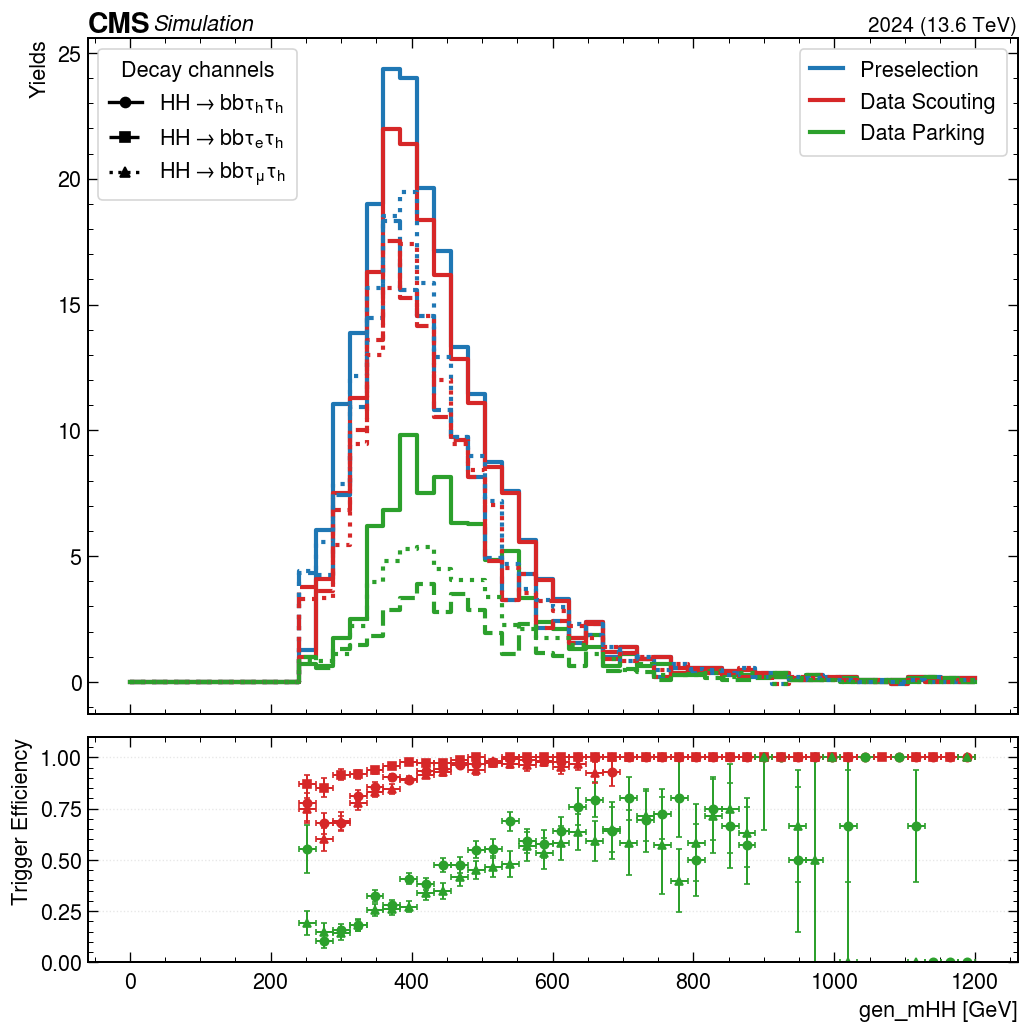

Info in <TEfficiency::TEfficiency>: given histograms are filled with weights
Info in <TROOT::TEfficiency::SetUseWeightedEvents>: Handle weighted events for computing efficiency
Info in <TEfficiency::TEfficiency>: given histograms are filled with weights
Info in <TROOT::TEfficiency::SetUseWeightedEvents>: Handle weighted events for computing efficiency
Warning in <TEfficiency::GetEfficiencyErrorLow>: frequentist confidence intervals for weights are only supported by the normal approximation
Info in <TEfficiency::GetEfficiencyErrorLow>: setting statistic option to kFNormal
Warning in <TEfficiency::GetEfficiencyErrorLow>: frequentist confidence intervals for weights are only supported by the normal approximation
Info in <TEfficiency::GetEfficiencyErrorLow>: setting statistic option to kFNormal
Info in <TEfficiency::TEfficiency>: given histograms are filled with weights
Info in <TROOT::TEfficiency::SetUseWeightedEvents>: Handle weighted events for computing efficiency
Info in <TROOT::TEffi

In [63]:
DST_ALL_expr = f"(({DST_MU_expr}) || ({DST_EL_expr}) || ({DST_JetHT_expr}))"

sig_df_acc = (sig_df
    .Filter("fabs(gen_eta_Hbb) < 2.5 && fabs(gen_eta_Htautau) < 2.5")
    .Filter("gen_pt_Hbb > 20.0 && gen_pt_Htautau > 40.0")
)

sig_df_hh = sig_df_acc.Filter("GenDecay.decayType==1")
sig_df_hm = sig_df_acc.Filter("GenDecay.decayType==2")
sig_df_he = sig_df_acc.Filter("GenDecay.decayType==3")

channels = [
    {"key":"hh", "label": r"HH$\rightarrow$bb$\tau_h\tau_h$", "df": sig_df_hh, "ls":"-",  "marker":"o"},
    {"key":"hm", "label": r"HH$\rightarrow$bb$\tau_e\tau_h$", "df": sig_df_hm, "ls":"--", "marker":"s"},
    {"key":"he", "label": r"HH$\rightarrow$bb$\tau_\mu\tau_h$", "df": sig_df_he, "ls":":",  "marker":"^"},
]

triggers = [
    {"key":"dst_all", "expr": DST_ALL_expr, "label":"Data Scouting"},
    {"key":"park",  "expr":PARKING_HH_expr, "label":"Data Parking"},
]

trigger_colors  = {
    "pre":  "tab:blue",
    "nom":  "tab:orange",
    "park": "tab:green",
    "dst_all":  "tab:red",
}

fig, ax, rax, out = plot_trigger_eff_overlay_channels(
    channels, triggers, var="gen_mHH",
    trigger_colors=trigger_colors,
    nbins=50, xmin=0, xmax=1200,
    figsize=(10, 10), cms_font_size = 13
)
plt.show()